# PCA on Vehicle Trajectory Features
End-to-end Principal Components Analysis on the features extracted from `20241125-6.json` via `extract_features.py`.

## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load and Explore the Vehicle Data

In [2]:

import subprocess, sys

# ── CONFIG ─────────────────────────────────────────────────────────────────────
INPUT_JSON  = '20241003-7.json' #'20241125-6.json'
OUTPUT_CSV  = 'output_trajectory_features.csv'
POINTS      = 10    # path waypoints per trajectory (0 = no spatial encoding)

# ── Run extract_trajectory_features ───────────────────────────────────────────
result = subprocess.run(
    [sys.executable, 'extract_features.py', INPUT_JSON,
     OUTPUT_CSV, '-t', 'trajectory', '-p', str(POINTS)],
    capture_output=True, text=True
)
print(result.stdout[-3000:] if result.stdout else '(no stdout)')
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])
    raise RuntimeError('Feature extraction failed — see STDERR above.')
else:
    print(f'✓  Saved to {OUTPUT_CSV}')


(no stdout)
✓  Saved to output_trajectory_features.csv


In [3]:

df = pd.read_csv(OUTPUT_CSV)

# ── Drop duplicated object_ids (same vehicle seen multiple times) ──────────────
dup_mask = df['object_id'].duplicated(keep=False)
n_removed = dup_mask.sum()
df = df[~dup_mask].reset_index(drop=True)
print(f'Removed {n_removed:,} rows with duplicated object_ids  '
      f'({df["object_id"].nunique():,} unique trajectories remain)')

print('\nClass distribution:')
print(df['classification'].value_counts())
print('\nSub-class distribution:')
print(df['sub_classification'].value_counts())
df.head(3)


Removed 1,649 rows with duplicated object_ids  (10,927 unique trajectories remain)

Class distribution:
classification
VEHICLE          9308
PERSON           1320
LARGE_VEHICLE     182
BICYCLE           114
UNKNOWN             3
Name: count, dtype: int64

Sub-class distribution:
sub_classification
car           8436
pedestrian    1326
truck          873
bus            149
bicycle        108
trailer         33
Name: count, dtype: int64


,vel_min,vel_max,vel_mean,vel_std,acc_min,acc_max,acc_mean,acc_std,jerk_min,jerk_max,...,y_8,x_9,y_9,object_id,intersection_id,classification,sub_classification,obj_length,obj_width,obj_height
0,12.600397,14.827340,14.018748,0.770932,0.0,13.456300,2.050477,3.243290,0.001000,140.326601,...,-35.990087,0.89,-40.50,205315,7,VEHICLE,car,4.537643,1.975036,1.583071
1,7.040597,13.701460,12.868639,1.344252,0.0,27.808142,3.642713,5.353720,0.003627,300.108578,...,-65.894107,3.22,-73.30,205328,7,VEHICLE,car,4.588741,1.979815,1.603093
2,2.002498,8.100617,4.751292,1.878239,0.0,13.040220,2.255051,2.056242,0.000000,86.308045,...,1.384756,34.64,-3.76,205329,7,VEHICLE,car,4.671202,2.090606,1.692926


3,761 trajectories after range filter


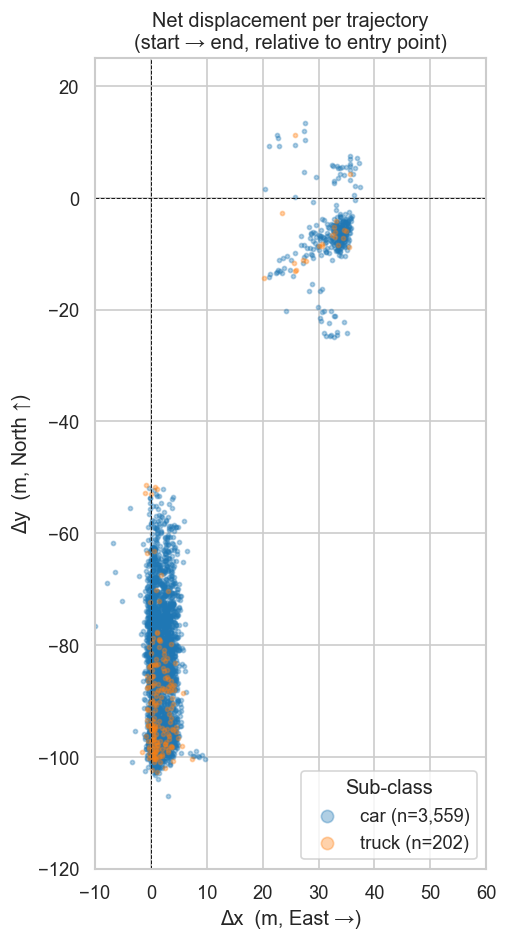

In [8]:

# --- Net displacement scatter: delta_x vs delta_y (all VEHICLE trajectories) ---
disp_df = df[df['classification'] == 'VEHICLE'][['delta_x', 'delta_y', 'sub_classification']].dropna()

# ── CONFIG ────────────────────────────────────────────────────────────────────
CLIP = 1.0   # percentile clip to suppress extreme outliers (ignored if ranges are set)

# Paired 2D cells: row is kept if it falls inside ANY (DELTA_X_RANGE[i], DELTA_Y_RANGE[i]) box.
# Both lists must have the same length, or set both to None for no filter.
# Examples:
#   one cell    : DELTA_X_RANGE=[(-10, 10)],      DELTA_Y_RANGE=[(-120, -50)]
#   two cells   : DELTA_X_RANGE=[(-10, 10), (20, 60)], DELTA_Y_RANGE=[(-120, -50), (50, 100)]
DELTA_X_RANGE = [(-10, 10), (20, 60)]
DELTA_Y_RANGE = [(-120, -50), (-25, 25)]

# DELTA_X_RANGE = None
# DELTA_Y_RANGE = None

# ── Helper: mask rows matching ANY paired (x_range[i], y_range[i]) box ───────
def _range_mask(dx, dy, x_ranges, y_ranges):
    """Return boolean Series: True if (dx, dy) falls in at least one paired cell."""
    if x_ranges is None and y_ranges is None:
        return pd.Series(True, index=dx.index)
    assert x_ranges is not None and y_ranges is not None, \
        "DELTA_X_RANGE and DELTA_Y_RANGE must both be set or both be None"
    assert len(x_ranges) == len(y_ranges), \
        f"DELTA_X_RANGE and DELTA_Y_RANGE must have the same length (got {len(x_ranges)} vs {len(y_ranges)})"
    mask = pd.Series(False, index=dx.index)
    for (xlo, xhi), (ylo, yhi) in zip(x_ranges, y_ranges):
        mask |= dx.between(xlo, xhi) & dy.between(ylo, yhi)
    return mask

# ── Apply range filter ────────────────────────────────────────────────────────
disp_df = disp_df[_range_mask(disp_df['delta_x'], disp_df['delta_y'], DELTA_X_RANGE, DELTA_Y_RANGE)]
print(f'{len(disp_df):,} trajectories after range filter')

# ── Axis limits: union of all ranges if provided, else percentile clip ────────
if DELTA_X_RANGE is not None:
    xlim = (min(lo for lo, _ in DELTA_X_RANGE), max(hi for _, hi in DELTA_X_RANGE))
    ylim = (min(lo for lo, _ in DELTA_Y_RANGE), max(hi for _, hi in DELTA_Y_RANGE))
else:
    xlim = (np.percentile(disp_df['delta_x'], CLIP), np.percentile(disp_df['delta_x'], 100 - CLIP))
    ylim = (np.percentile(disp_df['delta_y'], CLIP), np.percentile(disp_df['delta_y'], 100 - CLIP))

palette = sns.color_palette('tab10', n_colors=disp_df['sub_classification'].nunique())
fig, ax = plt.subplots(figsize=(8, 8))

for color, (sc, grp) in zip(palette, disp_df.groupby('sub_classification')):
    ax.scatter(grp['delta_x'], grp['delta_y'],
               s=6, alpha=0.35, color=color, label=f'{sc} (n={len(grp):,})')

ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
ax.axvline(0, color='k', linewidth=0.6, linestyle='--')
ax.set(xlabel='Δx  (m, East →)', ylabel='Δy  (m, North ↑)',
       title='Net displacement per trajectory\n(start → end, relative to entry point)',
       aspect='equal', xlim=xlim, ylim=ylim)
ax.legend(markerscale=3, title='Sub-class')
plt.tight_layout()
plt.show()


In [9]:
# Summary statistics for numeric features
FEATURE_COLS = [
    c for c in df.columns
    if df[c].dtype == float and c not in ('object_id', 'intersection_id')
]
print(f'{len(FEATURE_COLS)} numeric feature columns')
df[FEATURE_COLS].describe().T[['mean','std','min','max']].style.background_gradient(axis=0)

54 numeric feature columns


,mean,std,min,max
vel_min,5.430062,3.851491,0.000000,19.437078
vel_max,10.370137,5.141230,0.000000,29.324563
vel_mean,8.955666,5.109332,0.000000,26.942199
vel_std,1.146656,0.800881,0.000000,5.878359
acc_min,0.002904,0.058579,0.000000,3.160819
acc_max,16.848942,11.459753,0.000000,104.534029
acc_mean,2.151199,1.151263,0.000000,10.972526
acc_std,2.895110,1.873467,0.000000,17.634435
jerk_min,0.040795,0.565818,0.000000,10.001788
jerk_max,165.615180,131.788729,0.000000,1693.486615


## 3. Preprocess the Data

Each row is now **one complete vehicle trajectory** through the intersection.

**Feature groups:**
| Group | Features | `MAGNITUDE_ONLY` |
|---|---|---|
| Speed | `vel_min/max/mean/std` | ✅ keep |
| Acceleration (magnitude) | `acc_min/max/mean/std` | ✅ keep |
| Jerk (magnitude) | `jerk_min/max/mean/std` | ✅ keep |
| Directional acc / jerk | `acc_dir_*/jerk_dir_*` | ✅ keep (captures braking vs accelerating, not travel direction) |
| Curvature | `curv_min/max/mean/std` | ✅ keep |
| Behaviour fractions | `frac_stop / frac_accel / frac_break` | ✅ keep |
| Path length & duration | `path`, `delta_t` | ✅ keep |
| Object size | `obj_length/width/height` | ✅ keep |
| Net displacement | `delta_x`, `delta_y` | ❌ drop |
| Path waypoints | `x_0..y_N` | ❌ drop |

**Configuration knobs:**
- `FILTER_CLASS` — object class to keep (`'VEHICLE'` or `None`).
- `MIN_SPEED` — minimum trajectory mean speed (m/s); removes parked / barely-moving objects.
- `MAGNITUDE_ONLY` — drop spatial/directional features (`delta_x/y`, `x_*/y_*`).


In [10]:

# ── CONFIG ─────────────────────────────────────────────────────────────────────
FILTER_CLASS    = 'VEHICLE'   # None = all classes
MIN_SPEED       = 5.0         # m/s — drop trajectories with vel_mean below this (removes parked objects)
MAGNITUDE_ONLY  = True        # True = drop spatial/directional cols (delta_x/y, path waypoints x_*/y_*)

# ── Class filter ───────────────────────────────────────────────────────────────
if FILTER_CLASS:
    data = df[df['classification'] == FILTER_CLASS].copy()
else:
    data = df.copy()

# ── Spatial range filter (from displacement scatter) ──────────────────────────
# Uses DELTA_X_RANGE / DELTA_Y_RANGE set in the displacement plot cell; None = no filter
before_spatial = len(data)
data = data[_range_mask(data['delta_x'], data['delta_y'], DELTA_X_RANGE, DELTA_Y_RANGE)]
if DELTA_X_RANGE is not None:
    print(f'Spatial range filter : {len(data):,}  (dropped {before_spatial - len(data):,})')
    for i, (xr, yr) in enumerate(zip(DELTA_X_RANGE, DELTA_Y_RANGE)):
        print(f'  Cell {i}: x={xr}  y={yr}')

# ── NaN / inf cleanup ──────────────────────────────────────────────────────────
data[FEATURE_COLS] = data[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
before_nan = len(data)
data = data.dropna(subset=FEATURE_COLS)
print(f'After class filter & NaN drop : {len(data):,}  (dropped {before_nan - len(data):,})')

# ── Speed filter ───────────────────────────────────────────────────────────────
before_speed = len(data)
data = data[data['vel_mean'] >= MIN_SPEED].copy()
print(f'\nSpeed filter  (vel_mean ≥ {MIN_SPEED} m/s = {MIN_SPEED*3.6:.1f} km/h)')
print(f'  Pass : {len(data):,}  ({len(data)/before_speed*100:.1f}%)')
print(f'  Drop : {before_speed - len(data):,}  ({(before_speed-len(data))/before_speed*100:.1f}%)')
print(f'\nSub-class breakdown:')
print(data['sub_classification'].value_counts().to_string())

# ── Feature selection ──────────────────────────────────────────────────────────
DIRECTIONAL_EXACT    = {'delta_x', 'delta_y'}
DIRECTIONAL_PREFIXES = ('x_', 'y_')

if MAGNITUDE_ONLY:
    active_cols = [
        c for c in FEATURE_COLS
        if c not in DIRECTIONAL_EXACT
        and not any(c.startswith(p) for p in DIRECTIONAL_PREFIXES)
    ]
    print(f'\nMAGNITUDE_ONLY=True — keeping {len(active_cols)}/{len(FEATURE_COLS)} features (dropped spatial/directional)')
else:
    active_cols = FEATURE_COLS
    print(f'\nMAGNITUDE_ONLY=False — using all {len(active_cols)} features')

# ── Scale ──────────────────────────────────────────────────────────────────────
X = data[active_cols].values
labels = data['sub_classification'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Final scaled shape: {X_scaled.shape}')


Spatial range filter : 3,761  (dropped 5,547)
  Cell 0: x=(-10, 10)  y=(-120, -50)
  Cell 1: x=(20, 60)  y=(-25, 25)
After class filter & NaN drop : 3,761  (dropped 0)

Speed filter  (vel_mean ≥ 5.0 m/s = 18.0 km/h)
  Pass : 3,426  (91.1%)
  Drop : 335  (8.9%)

Sub-class breakdown:
sub_classification
car      3246
truck     180

MAGNITUDE_ONLY=True — keeping 32/54 features (dropped spatial/directional)
Final scaled shape: (3426, 32)


## 4. Apply PCA

In [11]:
# Fit full PCA to inspect variance spectrum
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f'Components to explain 90% variance: {n_90}')
print(f'Components to explain 95% variance: {n_95}')

# Refit with 95% threshold for downstream use
N_COMPONENTS = n_95
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA output shape: {X_pca.shape}')

Components to explain 90% variance: 12
Components to explain 95% variance: 14
PCA output shape: (3426, 14)


## 5. Visualise PCA Results

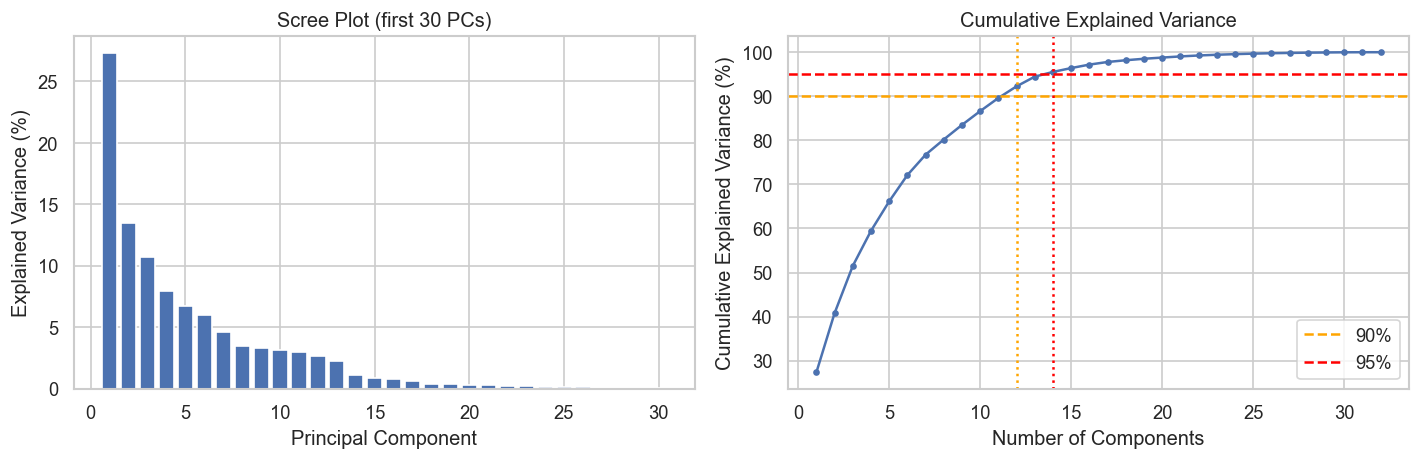

In [12]:

# --- 5a. Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

n_show = min(30, len(pca_full.explained_variance_ratio_))
axes[0].bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100)
axes[0].set(xlabel='Principal Component', ylabel='Explained Variance (%)',
            title='Scree Plot (first 30 PCs)')

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=3)
axes[1].axhline(90, color='orange', linestyle='--', label='90%')
axes[1].axhline(95, color='red',    linestyle='--', label='95%')
axes[1].axvline(n_90, color='orange', linestyle=':')
axes[1].axvline(n_95, color='red',    linestyle=':')
axes[1].set(xlabel='Number of Components', ylabel='Cumulative Explained Variance (%)',
            title='Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()


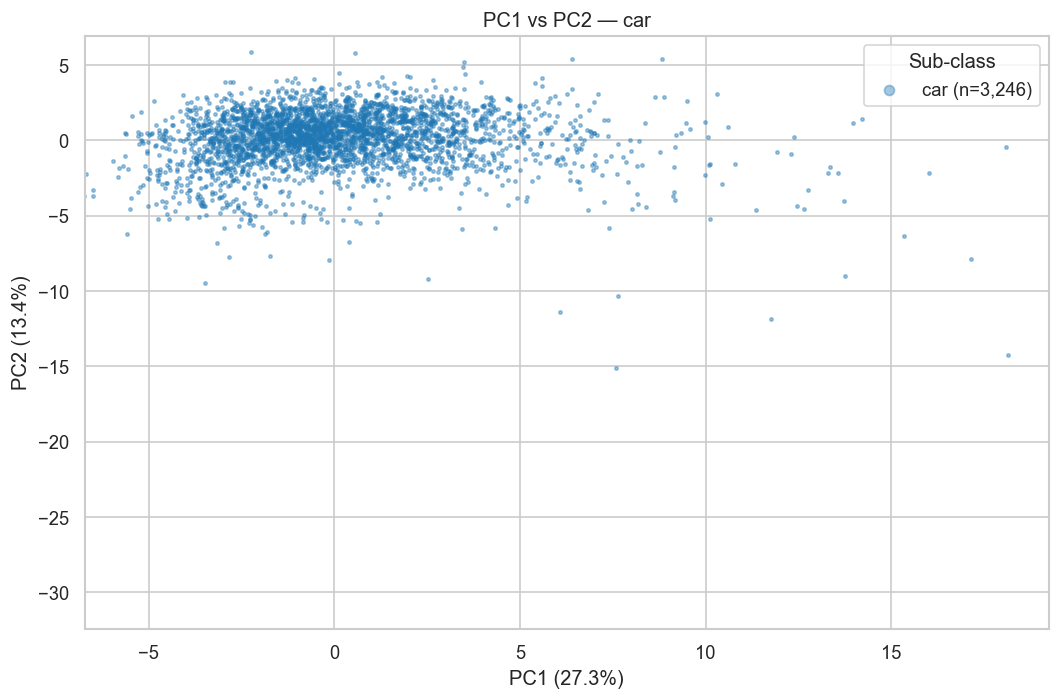

In [13]:

# --- 5b. PC1 vs PC2 scatter coloured by sub_classification ---
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Use None or [] to show ALL sub-classes
SHOW_SUBCLASSES_5B = ['car']   # e.g. ['car'], ['car', 'truck'], or None

MAX_POINTS  = 30_000
CLIP_PCT    = 0.01              # clip axes at this percentile on each side (e.g. 1 = 1%–99%)

# ── subsample ─────────────────────────────────────────────────────────────────
rng = np.random.default_rng(0)
idx = rng.choice(len(X_pca), size=min(MAX_POINTS, len(X_pca)), replace=False)

plot_df = pd.DataFrame({
    'PC1': X_pca[idx, 0],
    'PC2': X_pca[idx, 1],
    'sub_class': labels[idx]
})

# ── filter sub-classes ────────────────────────────────────────────────────────
if SHOW_SUBCLASSES_5B:
    missing = [s for s in SHOW_SUBCLASSES_5B if s not in plot_df['sub_class'].unique()]
    if missing:
        print(f"⚠️  Sub-classes not found in sample: {missing}")
        print(f"   Available: {sorted(plot_df['sub_class'].unique().tolist())}")
    plot_df = plot_df[plot_df['sub_class'].isin(SHOW_SUBCLASSES_5B)]

if plot_df.empty:
    raise ValueError("No data left after sub-class filter — check SHOW_SUBCLASSES_5B.")

# ── percentile-based axis limits ──────────────────────────────────────────────
xlim = (np.percentile(plot_df['PC1'], CLIP_PCT), np.percentile(plot_df['PC1'], 100 - CLIP_PCT))
ylim = (np.percentile(plot_df['PC2'], CLIP_PCT), np.percentile(plot_df['PC2'], 100 - CLIP_PCT))

# ── plot ──────────────────────────────────────────────────────────────────────
palette = sns.color_palette('tab10', n_colors=plot_df['sub_class'].nunique())
fig, ax = plt.subplots(figsize=(9, 6))
for color, (sc, grp) in zip(palette, plot_df.groupby('sub_class')):
    ax.scatter(grp['PC1'], grp['PC2'], s=4, alpha=0.4, color=color, label=f'{sc} (n={len(grp):,})')

title_suffix = ', '.join(SHOW_SUBCLASSES_5B) if SHOW_SUBCLASSES_5B else 'all sub-classes'
ax.set(xlabel=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
       ylabel=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
       title=f'PC1 vs PC2 — {title_suffix}',
       xlim=xlim, ylim=ylim)
ax.legend(markerscale=3, title='Sub-class')
plt.tight_layout()
plt.show()


## 6. Interpret Principal Components
A **loadings heatmap** shows which original features drive each PC.

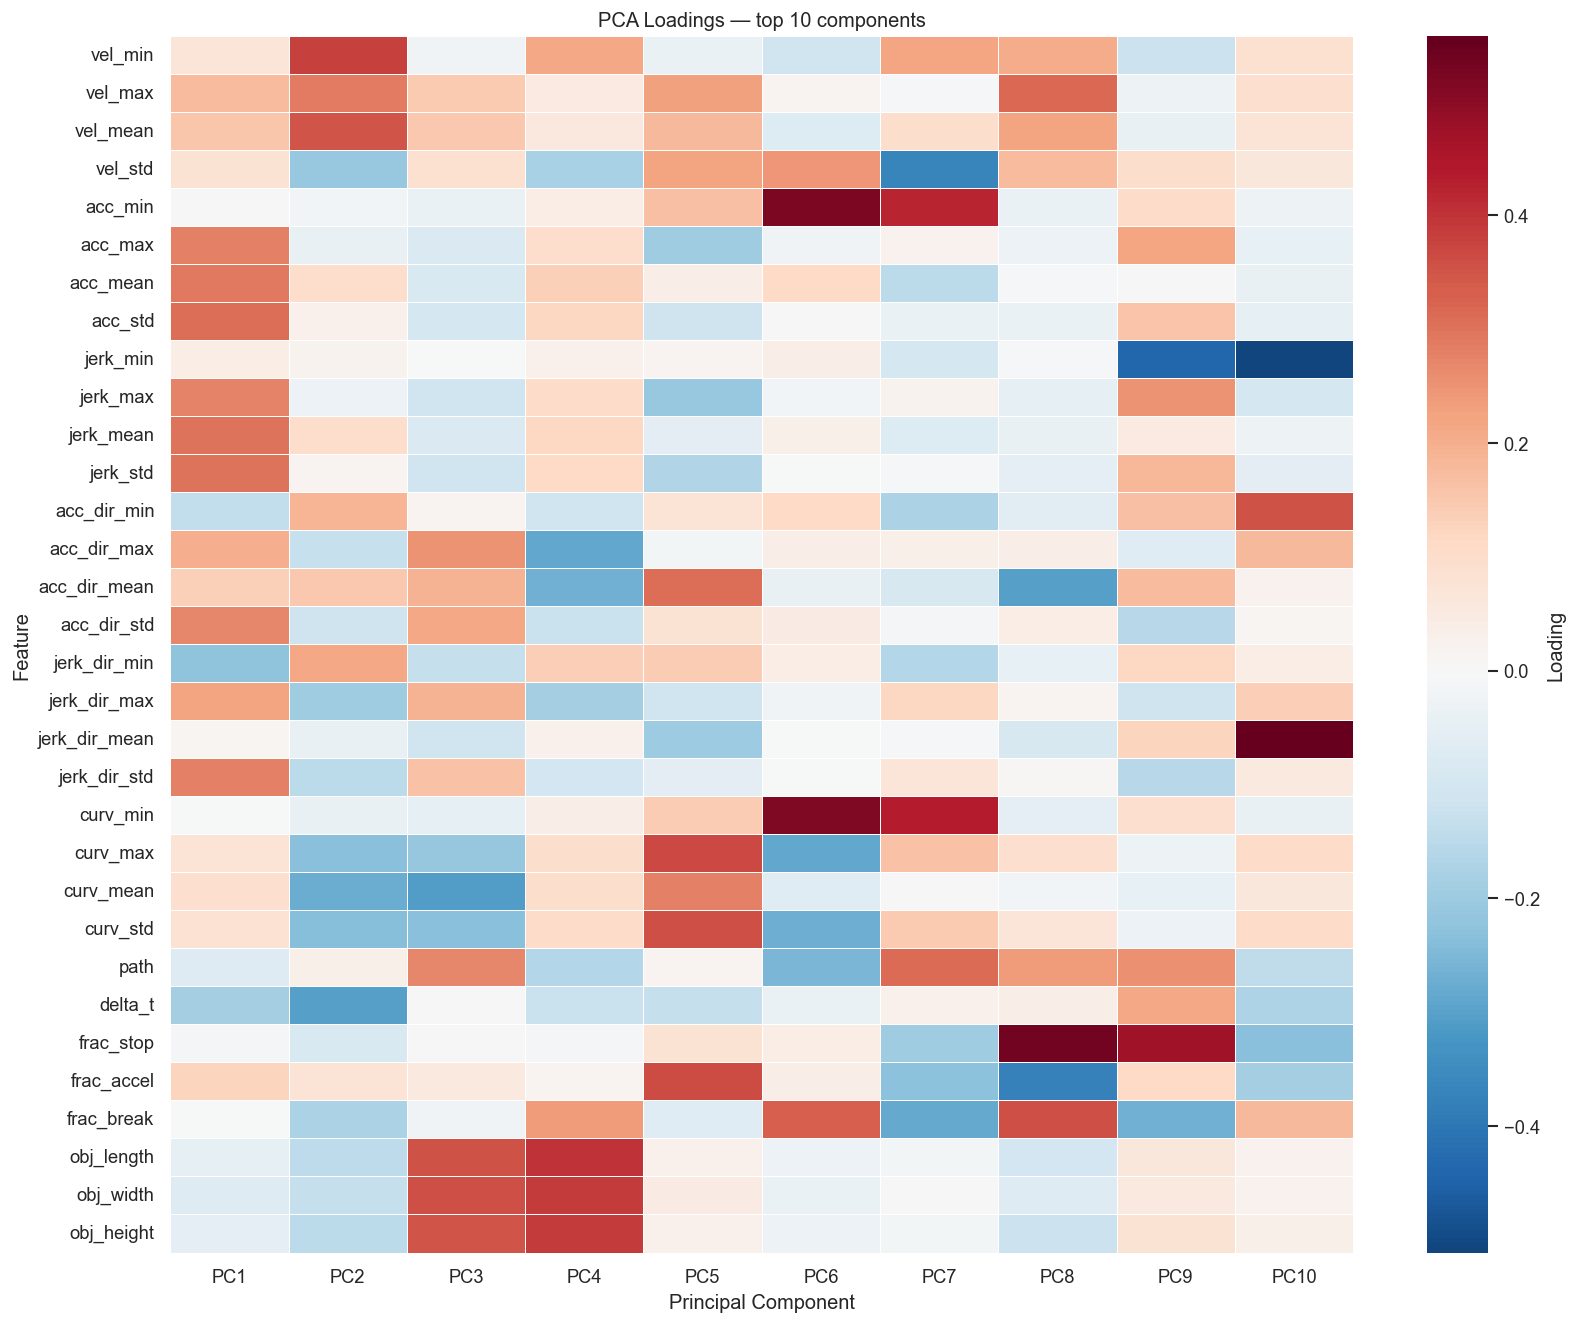

In [14]:

# --- 6a. Loadings heatmap for top 10 PCs ---
n_pc_show = min(10, pca.n_components_)
loadings = pd.DataFrame(
    pca.components_[:n_pc_show].T,
    index=active_cols,                          # active_cols reflects MAGNITUDE_ONLY choice
    columns=[f'PC{i+1}' for i in range(n_pc_show)]
)

fig, ax = plt.subplots(figsize=(14, max(6, len(active_cols) * 0.35)))
sns.heatmap(loadings, cmap='RdBu_r', center=0, linewidths=0.3,
            cbar_kws={'label': 'Loading'}, ax=ax)
ax.set(title=f'PCA Loadings — top {n_pc_show} components', xlabel='Principal Component', ylabel='Feature')
plt.tight_layout()
plt.show()


In [15]:

# --- 6b. Top contributing features per PC ---
N_TOP = min(8, len(active_cols))
for pc_idx in range(min(5, pca.n_components_)):
    top = loadings[f'PC{pc_idx+1}'].abs().nlargest(N_TOP)
    var = pca.explained_variance_ratio_[pc_idx] * 100
    print(f'\nPC{pc_idx+1}  ({var:.1f}% variance explained) — top {N_TOP} features:')
    for feat, loading in zip(top.index, loadings[f'PC{pc_idx+1}'][top.index]):
        bar = '█' * int(abs(loading) * 30)
        sign = '+' if loading > 0 else '-'
        print(f'  {sign}{bar:<30}  {feat}  ({loading:+.3f})')



PC1  (27.3% variance explained) — top 8 features:
  +█████████                       acc_std  (+0.307)
  +█████████                       jerk_mean  (+0.300)
  +████████                        jerk_std  (+0.300)
  +████████                        acc_mean  (+0.291)
  +████████                        acc_max  (+0.281)
  +████████                        jerk_dir_std  (+0.280)
  +████████                        jerk_max  (+0.274)
  +████████                        acc_dir_std  (+0.271)

PC2  (13.4% variance explained) — top 8 features:
  +███████████                     vel_min  (+0.379)
  +██████████                      vel_mean  (+0.351)
  -█████████                       delta_t  (-0.304)
  +████████                        vel_max  (+0.288)
  -████████                        curv_mean  (-0.274)
  -███████                         curv_std  (-0.236)
  -██████                          curv_max  (-0.233)
  +██████                          jerk_dir_min  (+0.215)

PC3  (10.7% variance expl

In [16]:
# --- 6c. Per-sub-class mean PC scores (centroid separation) ---
pc_df = pd.DataFrame(X_pca[:, :5],
                     columns=[f'PC{i+1}' for i in range(5)])
pc_df['sub_class'] = labels

centroids = pc_df.groupby('sub_class').mean().round(3)
print('\nMean PC scores by sub-class (PC1–PC5):')
centroids.style.background_gradient(cmap='RdBu_r', axis=None)


Mean PC scores by sub-class (PC1–PC5):


,PC1,PC2,PC3,PC4,PC5
sub_class,,,,,
car,0.109000,0.118000,-0.234000,-0.225000,-0.010000
truck,-1.967000,-2.131000,4.222000,4.060000,0.188000


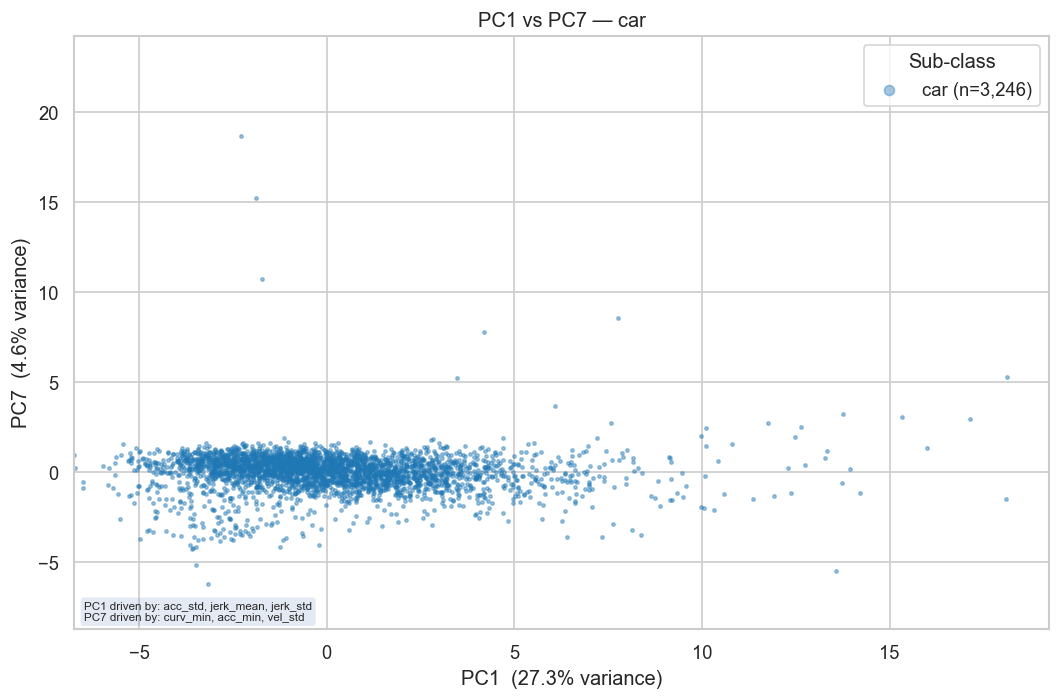

In [20]:

# --- Plot any pair of principal components ---
# ── CONFIG ────────────────────────────────────────────────────────────────────
PC_X = 1
PC_Y = 7

# Use None or an empty list to show ALL sub-classes
SHOW_SUBCLASSES = ['car']   # ← change this list as needed

MAX_POINTS  = 30_000
CLIP_PCT    = 0.01           # clip axes at this percentile on each side (e.g. 1 = 1%–99%)

# ── validation ────────────────────────────────────────────────────────────────
assert 1 <= PC_X <= pca.n_components_, f"PC_X must be between 1 and {pca.n_components_}"
assert 1 <= PC_Y <= pca.n_components_, f"PC_Y must be between 1 and {pca.n_components_}"
assert PC_X != PC_Y, "PC_X and PC_Y must be different"

# ── subsample ─────────────────────────────────────────────────────────────────
rng = np.random.default_rng(0)
idx = rng.choice(len(X_pca), size=min(MAX_POINTS, len(X_pca)), replace=False)

plot_df = pd.DataFrame({
    f'PC{PC_X}': X_pca[idx, PC_X - 1],
    f'PC{PC_Y}': X_pca[idx, PC_Y - 1],
    'sub_class': labels[idx],
})

# ── filter sub-classes ────────────────────────────────────────────────────────
if SHOW_SUBCLASSES:
    missing = [s for s in SHOW_SUBCLASSES if s not in plot_df['sub_class'].unique()]
    if missing:
        print(f"⚠️  Sub-classes not found in sample: {missing}")
        print(f"   Available: {sorted(plot_df['sub_class'].unique().tolist())}")
    plot_df = plot_df[plot_df['sub_class'].isin(SHOW_SUBCLASSES)]

if plot_df.empty:
    raise ValueError("No data left after sub-class filter — check SHOW_SUBCLASSES.")

# ── percentile-based axis limits ──────────────────────────────────────────────
xlim = (np.percentile(plot_df[f'PC{PC_X}'], CLIP_PCT), np.percentile(plot_df[f'PC{PC_X}'], 100 - CLIP_PCT))
ylim = (np.percentile(plot_df[f'PC{PC_Y}'], CLIP_PCT), np.percentile(plot_df[f'PC{PC_Y}'], 100 - CLIP_PCT))

# ── plot ──────────────────────────────────────────────────────────────────────
palette = sns.color_palette('tab10', n_colors=plot_df['sub_class'].nunique())
fig, ax = plt.subplots(figsize=(9, 6))

for color, (sc, grp) in zip(palette, plot_df.groupby('sub_class')):
    ax.scatter(grp[f'PC{PC_X}'], grp[f'PC{PC_Y}'], s=4, alpha=0.4, color=color, label=f'{sc} (n={len(grp):,})')

var_x = pca.explained_variance_ratio_[PC_X - 1] * 100
var_y = pca.explained_variance_ratio_[PC_Y - 1] * 100
ax.set(
    xlabel=f'PC{PC_X}  ({var_x:.1f}% variance)',
    ylabel=f'PC{PC_Y}  ({var_y:.1f}% variance)',
    title=f'PC{PC_X} vs PC{PC_Y} — {", ".join(SHOW_SUBCLASSES) if SHOW_SUBCLASSES else "all sub-classes"}',
    xlim=xlim, ylim=ylim,
)
ax.legend(markerscale=3, title='Sub-class')

# ── top-3 driving features annotated ─────────────────────────────────────────
top_x = loadings[f'PC{PC_X}'].abs().nlargest(3).index.tolist()
top_y = loadings[f'PC{PC_Y}'].abs().nlargest(3).index.tolist()
note = (f"PC{PC_X} driven by: {', '.join(top_x)}\n"
        f"PC{PC_Y} driven by: {', '.join(top_y)}")
ax.text(0.01, 0.01, note, transform=ax.transAxes, fontsize=7,
        verticalalignment='bottom', bbox=dict(boxstyle='round,pad=0.3', alpha=0.15))

plt.tight_layout()
plt.show()


## 7. Outlier Trajectory Detection

Use **Isolation Forest** on the PCA-reduced representation to flag anomalous trajectories — vehicles with unusual speed profiles, acceleration patterns, or path shapes.

- `OUTLIER_CONTAMINATION` — expected fraction of outliers (e.g. `0.05` = 5%).
- Anomaly score: lower = more anomalous.

In [18]:

from sklearn.ensemble import IsolationForest

# ── CONFIG ─────────────────────────────────────────────────────────────────────
OUTLIER_CONTAMINATION = 0.05   # expected fraction of outliers

# ── Fit Isolation Forest on PCA scores ────────────────────────────────────────
iso = IsolationForest(contamination=OUTLIER_CONTAMINATION, random_state=42, n_jobs=-1)
outlier_pred   = iso.fit_predict(X_pca)      # -1 = outlier, 1 = inlier
outlier_scores = iso.score_samples(X_pca)   # lower = more anomalous

result_df = data.reset_index(drop=True).copy()
result_df['outlier']       = outlier_pred == -1
result_df['anomaly_score'] = outlier_scores

n_out = result_df['outlier'].sum()
print(f'Outliers detected : {n_out} / {len(result_df)}  ({n_out/len(result_df)*100:.1f}%)')
print('\nOutlier count by sub-class:')
print(result_df.groupby('sub_classification')[['outlier']].sum().join(
    result_df.groupby('sub_classification').size().rename('total')
).assign(pct=lambda d: (d['outlier']/d['total']*100).round(1)).to_string())


Outliers detected : 172 / 3426  (5.0%)

Outlier count by sub-class:
                    outlier  total   pct
sub_classification                      
car                     140   3246   4.3
truck                    32    180  17.8


In [15]:

# ── 7c. Inspect the most anomalous trajectories ───────────────────────────────
N_SHOW = 15

display_cols = [
    'object_id', 'sub_classification', 'anomaly_score',
    'vel_mean', 'vel_max', 'vel_std',
    'acc_max', 'acc_dir_min', 'acc_dir_max',
    'jerk_max', 'curv_max',
    'path', 'delta_t',
    'frac_stop', 'frac_accel', 'frac_break',
]
# Keep only columns that actually exist in result_df (depends on POINTS setting)
display_cols = [c for c in display_cols if c in result_df.columns]

top_outliers = result_df.nsmallest(N_SHOW, 'anomaly_score')[display_cols].round(3)
print(f'Top {N_SHOW} most anomalous trajectories:')
top_outliers.style \
    .background_gradient(cmap='Reds_r', subset=['anomaly_score']) \
    .background_gradient(cmap='YlOrRd', subset=[c for c in ['vel_max', 'acc_max', 'jerk_max', 'curv_max'] if c in display_cols])


Top 15 most anomalous trajectories:


,object_id,sub_classification,anomaly_score,vel_mean,vel_max,vel_std,acc_max,acc_dir_min,acc_dir_max,jerk_max,curv_max,path,delta_t,frac_stop,frac_accel,frac_break
3101,289527,truck,-0.760000,7.744000,14.506000,5.878000,11.405000,-11.038000,10.927000,110.314000,1.677000,98.876000,13.300000,0.316000,0.173000,0.301000
2286,267075,car,-0.742000,8.189000,11.804000,2.145000,50.499000,-45.941000,20.214000,505.212000,40.743000,76.098000,7.900000,0.000000,0.329000,0.101000
1472,243083,car,-0.723000,5.313000,11.300000,3.968000,12.531000,-10.883000,7.735000,139.308000,3.018000,104.298000,17.903000,0.218000,0.290000,0.066000
3376,300880,car,-0.716000,10.354000,11.904000,2.133000,9.431000,-4.447000,6.941000,80.624000,0.083000,104.044000,15.200000,0.408000,0.118000,0.447000
1628,248013,car,-0.692000,5.014000,11.000000,3.631000,19.854000,-13.501000,7.031000,255.053000,0.284000,82.901000,16.500000,0.170000,0.261000,0.303000
1629,248045,car,-0.689000,6.022000,14.812000,3.719000,51.895000,-32.864000,37.491000,961.187000,1.697000,77.989000,12.900000,0.109000,0.287000,0.333000
1932,258101,car,-0.689000,10.109000,11.600000,1.705000,99.557000,-75.226000,11.685000,1012.830000,7.106000,75.011000,6.600000,0.000000,0.379000,0.121000
2750,278414,car,-0.679000,17.691000,19.002000,1.340000,37.222000,-8.154000,17.989000,305.974000,0.129000,81.939000,4.500000,0.000000,0.422000,0.333000
1537,245802,car,-0.678000,14.193000,23.149000,2.153000,61.676000,-29.177000,3.994000,577.161000,0.176000,73.290000,5.500000,0.000000,0.109000,0.273000
2845,281830,car,-0.676000,11.969000,13.806000,2.947000,34.066000,-30.576000,24.512000,331.159000,0.375000,64.498000,4.700000,0.043000,0.340000,0.149000
